# Welcome to Cloud Lab


In [2]:
pip install simpy


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import simpy


# Cloud Task (Cloudlet)
def cloud_task(env, name, vm, execution_time):
    print(f"{name} arrived at time {env.now}")

    # Request a Virtual Machine (VM)
    with vm.request() as request:
        yield request

        print(f"{name} started execution at time {env.now}")

        # Simulate execution
        yield env.timeout(execution_time)

        print(f"{name} completed at time {env.now}")


# Create simulation environment
env = simpy.Environment()

# Create one Virtual Machine (capacity = 1)
vm = simpy.Resource(env, capacity=1)

# Create Cloudlets
env.process(cloud_task(env, "Cloudlet-1", vm, 4))
env.process(cloud_task(env, "Cloudlet-2", vm, 3))
env.process(cloud_task(env, "Cloudlet-3", vm, 5))

# Run simulation
env.run()

Cloudlet-1 arrived at time 0
Cloudlet-2 arrived at time 0
Cloudlet-3 arrived at time 0
Cloudlet-1 started execution at time 0
Cloudlet-1 completed at time 4
Cloudlet-2 started execution at time 4
Cloudlet-2 completed at time 7
Cloudlet-3 started execution at time 7
Cloudlet-3 completed at time 12


#  Implement different task scheduling algorithms like FCFS, Round Robin, SJF, Maxmin Min-min algorithms etc. using cloud Simulator. 

              FCFS SCHEDULING RESULTS
  Task  Burst Time  Waiting Time  Completion Time  Turnaround Time
0   T1          10             0               10               10
1   T2           4            10               14               14
2   T3           6            14               20               20
3   T4           8            20               28               28
4   T5           2            28               30               30

Average Waiting Time    : 14.4
Average Turnaround Time : 20.4
Makespan                : 30


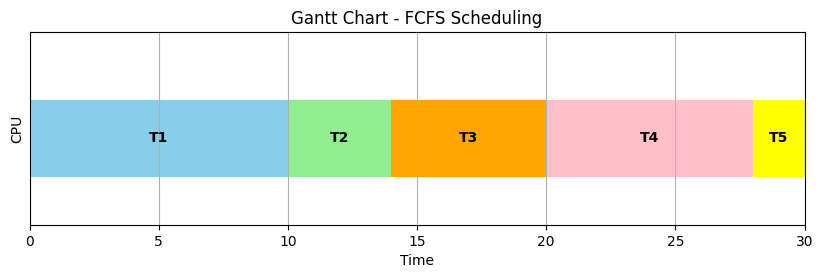

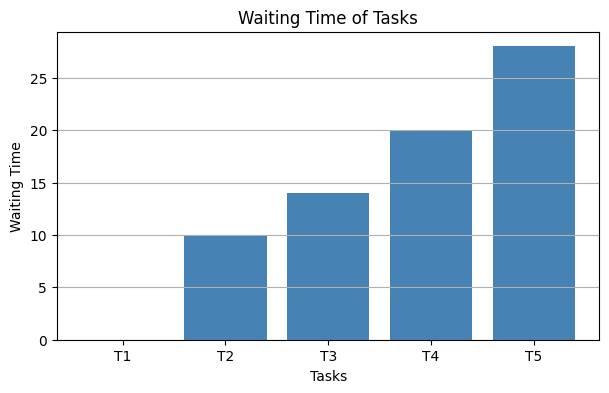

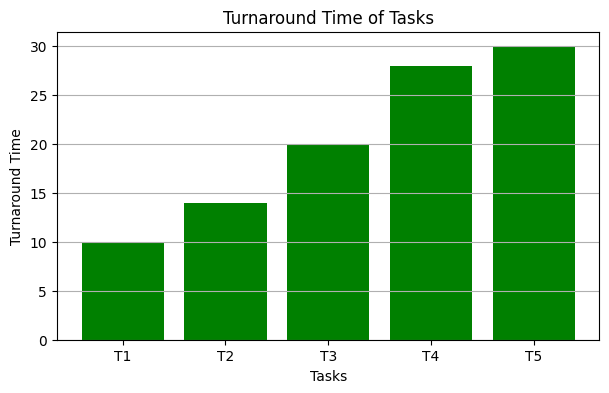


Program Executed Successfully.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Input Tasks
# -----------------------------
# Format: (Task Name, Burst Time)

tasks = [
    ("T1", 10),
    ("T2", 4),
    ("T3", 6),
    ("T4", 8),
    ("T5", 2)
]

# -----------------------------
# FCFS Scheduling
# -----------------------------

waiting_time = []
turnaround_time = []
completion_time = []

current_time = 0

for task, burst in tasks:

    # Waiting time is the current CPU time
    waiting_time.append(current_time)

    # Execute task
    current_time += burst

    # Completion time
    completion_time.append(current_time)

    # Since arrival time is 0 for all tasks
    turnaround_time.append(current_time)

# -----------------------------
# Create Result Table
# -----------------------------

result = pd.DataFrame({
    "Task": [task for task, burst in tasks],
    "Burst Time": [burst for task, burst in tasks],
    "Waiting Time": waiting_time,
    "Completion Time": completion_time,
    "Turnaround Time": turnaround_time
})

# -----------------------------
# Display Results
# -----------------------------

print("=" * 60)
print("              FCFS SCHEDULING RESULTS")
print("=" * 60)

print(result)

# -----------------------------
# Calculate Averages
# -----------------------------

avg_wait = result["Waiting Time"].mean()
avg_turn = result["Turnaround Time"].mean()

print("\nAverage Waiting Time    :", round(avg_wait, 2))
print("Average Turnaround Time :", round(avg_turn, 2))
print("Makespan                :", completion_time[-1])

# -----------------------------
# Gantt Chart
# -----------------------------

fig, ax = plt.subplots(figsize=(10, 2.5))

start = 0

colors = ['skyblue', 'lightgreen', 'orange', 'pink', 'yellow']

for i, (task, burst) in enumerate(tasks):

    ax.broken_barh(
        [(start, burst)],
        (10, 8),
        facecolors=colors[i % len(colors)]
    )

    ax.text(
        start + burst / 2,
        14,
        task,
        ha='center',
        va='center',
        fontsize=10,
        fontweight='bold'
    )

    start += burst

ax.set_ylim(5, 25)
ax.set_xlim(0, completion_time[-1])

ax.set_xlabel("Time")
ax.set_ylabel("CPU")
ax.set_title("Gantt Chart - FCFS Scheduling")

ax.set_yticks([])

ax.grid(True)

plt.show()

# -----------------------------
# Waiting Time Graph
# -----------------------------

plt.figure(figsize=(7, 4))

plt.bar(result["Task"], result["Waiting Time"], color="steelblue")

plt.title("Waiting Time of Tasks")
plt.xlabel("Tasks")
plt.ylabel("Waiting Time")

plt.grid(axis='y')

plt.show()

# -----------------------------
# Turnaround Time Graph
# -----------------------------

plt.figure(figsize=(7, 4))

plt.bar(result["Task"], result["Turnaround Time"], color="green")

plt.title("Turnaround Time of Tasks")
plt.xlabel("Tasks")
plt.ylabel("Turnaround Time")

plt.grid(axis='y')

plt.show()

print("\nProgram Executed Successfully.")


               ROUND ROBIN SCHEDULING
Task    Burst       Waiting        Turnaround     Completion     
T1      10          20             30             30             
T2      4           10             14             14             
T3      6           16             22             22             
T4      8           20             28             28             
T5      2           8              10             10             

Performance Metrics
----------------------------------------
Average Waiting Time    : 14.8
Average Turnaround Time : 20.8
Makespan               : 30
CPU Utilization        : 100.0 %
Throughput             : 0.167 Tasks/Unit Time


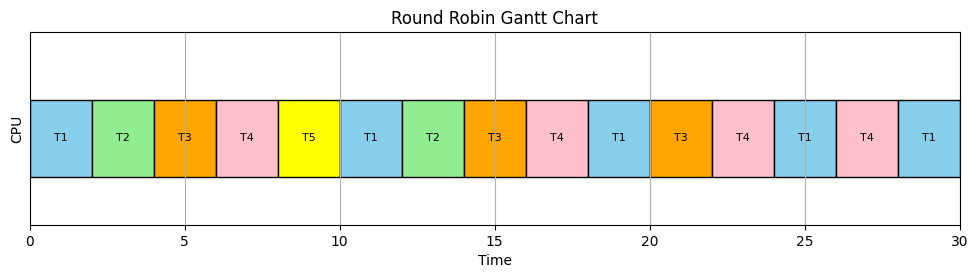

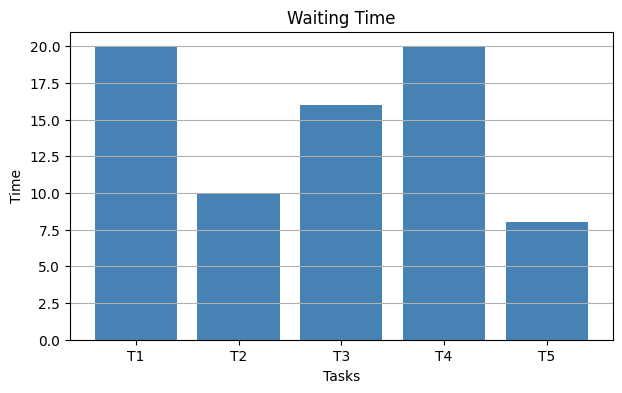

In [2]:
# ============================================================
# Round Robin Scheduling Algorithm
# Cloud Computing Lab
# ============================================================

import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Input Tasks
# Format: (Task Name, Burst Time)
# ------------------------------------------------------------

tasks = [
    ("T1", 10),
    ("T2", 4),
    ("T3", 6),
    ("T4", 8),
    ("T5", 2)
]

# Time Quantum
quantum = 2

# ------------------------------------------------------------
# Initialization
# ------------------------------------------------------------

n = len(tasks)

task_names = [task[0] for task in tasks]
burst_time = [task[1] for task in tasks]

remaining_time = burst_time.copy()

completion_time = [0] * n
waiting_time = [0] * n
turnaround_time = [0] * n

time = 0

gantt = []

# ------------------------------------------------------------
# Round Robin Scheduling
# ------------------------------------------------------------

while True:

    done = True

    for i in range(n):

        if remaining_time[i] > 0:

            done = False

            start = time

            if remaining_time[i] > quantum:

                time += quantum
                remaining_time[i] -= quantum

                gantt.append((task_names[i], start, time))

            else:

                time += remaining_time[i]

                gantt.append((task_names[i], start, time))

                completion_time[i] = time

                turnaround_time[i] = completion_time[i]

                waiting_time[i] = turnaround_time[i] - burst_time[i]

                remaining_time[i] = 0

    if done:
        break

# ------------------------------------------------------------
# Display Results
# ------------------------------------------------------------

print("=" * 75)
print("               ROUND ROBIN SCHEDULING")
print("=" * 75)

print("{:<8}{:<12}{:<15}{:<15}{:<15}".format(
    "Task",
    "Burst",
    "Waiting",
    "Turnaround",
    "Completion"))

for i in range(n):

    print("{:<8}{:<12}{:<15}{:<15}{:<15}".format(
        task_names[i],
        burst_time[i],
        waiting_time[i],
        turnaround_time[i],
        completion_time[i]))

# ------------------------------------------------------------
# Performance Metrics
# ------------------------------------------------------------

avg_wait = sum(waiting_time) / n
avg_turn = sum(turnaround_time) / n
makespan = max(completion_time)

cpu_util = (sum(burst_time) / makespan) * 100

throughput = n / makespan

print("\nPerformance Metrics")
print("-" * 40)

print("Average Waiting Time    :", round(avg_wait, 2))
print("Average Turnaround Time :", round(avg_turn, 2))
print("Makespan               :", makespan)
print("CPU Utilization        :", round(cpu_util, 2), "%")
print("Throughput             :", round(throughput, 3), "Tasks/Unit Time")

# ------------------------------------------------------------
# Gantt Chart
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 2.5))

colors = ['skyblue', 'lightgreen', 'orange', 'pink', 'yellow']

for item in gantt:

    task, start, end = item

    ax.broken_barh(
        [(start, end - start)],
        (10, 8),
        facecolors=colors[task_names.index(task) % len(colors)],
        edgecolor='black'
    )

    ax.text(
        (start + end) / 2,
        14,
        task,
        ha='center',
        va='center',
        fontsize=8
    )

ax.set_xlim(0, makespan)
ax.set_ylim(5, 25)

ax.set_xlabel("Time")
ax.set_ylabel("CPU")
ax.set_yticks([])

ax.set_title("Round Robin Gantt Chart")

ax.grid(True)

plt.show()

# ------------------------------------------------------------
# Waiting Time Graph
# ------------------------------------------------------------

plt.figure(figsize=(7, 4))

plt.bar(task_names, waiting_time, color="steelblue")

plt.title("Waiting Time")

plt.xlabel("Tasks")
plt.ylabel("Time")

plt.grid(axis='y')

plt.show()

#


           SHORTEST JOB FIRST (SJF) SCHEDULING
Task    Burst       Waiting        Turnaround     Completion     
T5      2           0              2              2              
T2      4           2              6              6              
T3      6           6              12             12             
T4      8           12             20             20             
T1      10          20             30             30             

Performance Metrics
----------------------------------------
Average Waiting Time    : 8.0
Average Turnaround Time : 14.0
Makespan               : 30
CPU Utilization        : 100.0 %
Throughput             : 0.167 Tasks/Unit Time


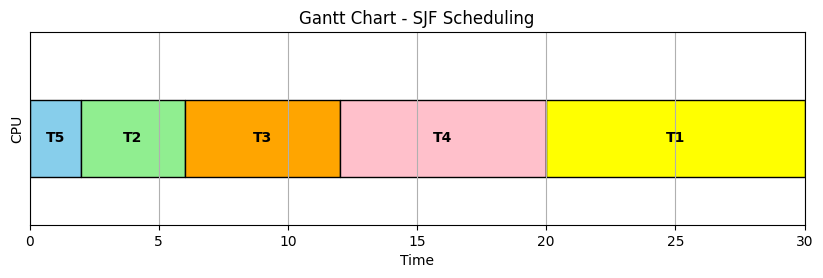

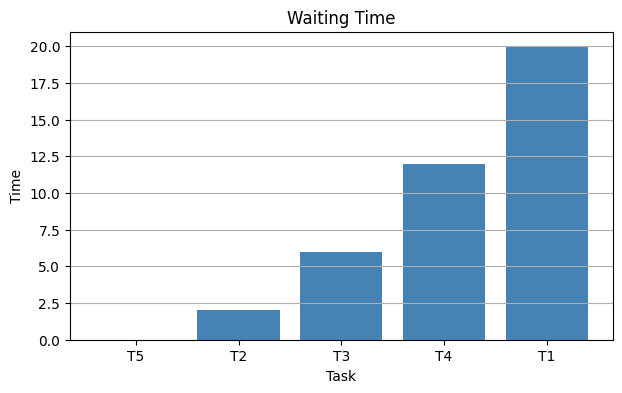

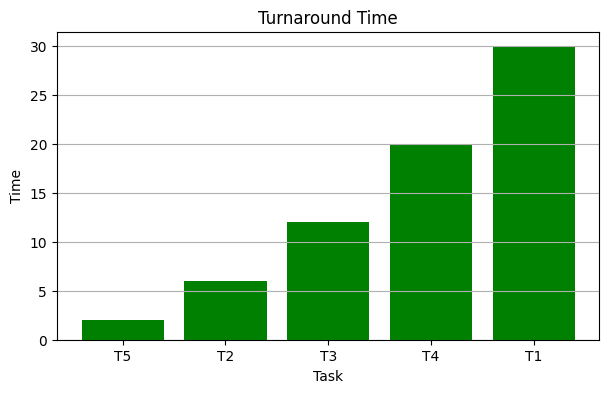


SJF Scheduling Completed Successfully.


In [3]:


# ============================================================
# Shortest Job First (SJF) Scheduling Algorithm
# Cloud Computing Lab
# ============================================================

import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Input Tasks
# Format: (Task Name, Burst Time)
# ------------------------------------------------------------

tasks = [
    ("T1", 10),
    ("T2", 4),
    ("T3", 6),
    ("T4", 8),
    ("T5", 2)
]

# ------------------------------------------------------------
# Sort Tasks by Burst Time (Shortest Job First)
# ------------------------------------------------------------

tasks = sorted(tasks, key=lambda x: x[1])

task_names = []
burst_times = []
waiting_times = []
turnaround_times = []
completion_times = []

current_time = 0

for task, burst in tasks:

    task_names.append(task)
    burst_times.append(burst)

    # Waiting Time
    waiting_times.append(current_time)

    # Execute Task
    current_time += burst

    # Completion Time
    completion_times.append(current_time)

    # Since Arrival Time = 0
    turnaround_times.append(current_time)

# ------------------------------------------------------------
# Display Results
# ------------------------------------------------------------

print("=" * 75)
print("           SHORTEST JOB FIRST (SJF) SCHEDULING")
print("=" * 75)

print("{:<8}{:<12}{:<15}{:<15}{:<15}".format(
    "Task",
    "Burst",
    "Waiting",
    "Turnaround",
    "Completion"
))

for i in range(len(tasks)):

    print("{:<8}{:<12}{:<15}{:<15}{:<15}".format(
        task_names[i],
        burst_times[i],
        waiting_times[i],
        turnaround_times[i],
        completion_times[i]
    ))

# ------------------------------------------------------------
# Performance Metrics
# ------------------------------------------------------------

avg_wait = sum(waiting_times) / len(tasks)
avg_turn = sum(turnaround_times) / len(tasks)
makespan = completion_times[-1]

cpu_util = (sum(burst_times) / makespan) * 100
throughput = len(tasks) / makespan

print("\nPerformance Metrics")
print("-" * 40)

print("Average Waiting Time    :", round(avg_wait, 2))
print("Average Turnaround Time :", round(avg_turn, 2))
print("Makespan               :", makespan)
print("CPU Utilization        :", round(cpu_util, 2), "%")
print("Throughput             :", round(throughput, 3), "Tasks/Unit Time")

# ------------------------------------------------------------
# Gantt Chart
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 2.5))

colors = ['skyblue', 'lightgreen', 'orange', 'pink', 'yellow']

start = 0

for i in range(len(tasks)):

    burst = burst_times[i]

    ax.broken_barh(
        [(start, burst)],
        (10, 8),
        facecolors=colors[i % len(colors)],
        edgecolor='black'
    )

    ax.text(
        start + burst / 2,
        14,
        task_names[i],
        ha='center',
        va='center',
        fontsize=10,
        fontweight='bold'
    )

    start += burst

ax.set_xlim(0, makespan)
ax.set_ylim(5, 25)

ax.set_xlabel("Time")
ax.set_ylabel("CPU")
ax.set_yticks([])

ax.set_title("Gantt Chart - SJF Scheduling")

ax.grid(True)

plt.show()

# ------------------------------------------------------------
# Waiting Time Graph
# ------------------------------------------------------------

plt.figure(figsize=(7, 4))

plt.bar(task_names, waiting_times, color="steelblue")

plt.title("Waiting Time")

plt.xlabel("Task")
plt.ylabel("Time")

plt.grid(axis='y')

plt.show()

# ------------------------------------------------------------
# Turnaround Time Graph
# ------------------------------------------------------------

plt.figure(figsize=(7, 4))

plt.bar(task_names, turnaround_times, color="green")

plt.title("Turnaround Time")

plt.xlabel("Task")
plt.ylabel("Time")

plt.grid(axis='y')

plt.show()

print("\nSJF Scheduling Completed Successfully.")


                    MAX-MIN TASK SCHEDULING
Task    VM      Start       Finish      
T2      VM1     0           16          
T1      VM2     0           10          
T3      VM3     0           10          
T4      VM3     10          16          
T5      VM2     10          14          

Performance Metrics
----------------------------------------
Makespan : 16
VM1 Completion Time : 16
VM2 Completion Time : 14
VM3 Completion Time : 16


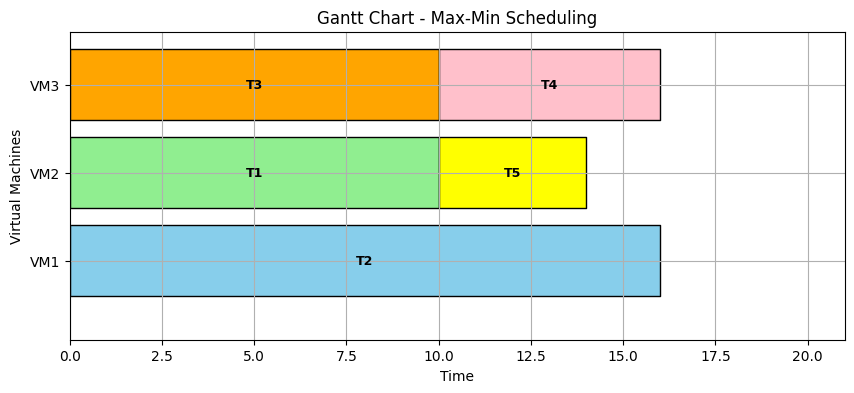

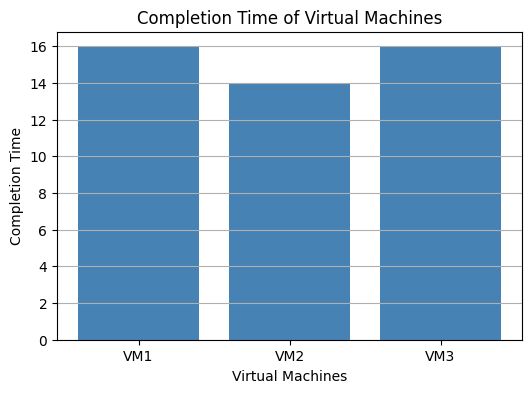


Max-Min Scheduling Completed Successfully.


In [4]:
# ============================================================
# Max-Min Scheduling Algorithm
# Cloud Computing Lab
# ============================================================

import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Execution Time Matrix
# Rows = Tasks
# Columns = Virtual Machines (VMs)
# ------------------------------------------------------------

tasks = ["T1", "T2", "T3", "T4", "T5"]
vms = ["VM1", "VM2", "VM3"]

execution_time = [
    [14, 10, 12],   # T1
    [16, 20, 18],   # T2
    [9,  12, 10],   # T3
    [7,  8,  6],    # T4
    [5,  4,  7]     # T5
]

# ------------------------------------------------------------
# Initialization
# ------------------------------------------------------------

machine_ready = [0] * len(vms)
remaining_tasks = list(range(len(tasks)))

schedule = []

# ------------------------------------------------------------
# Max-Min Scheduling
# ------------------------------------------------------------

while remaining_tasks:

    minimum_completion = []

    # Find minimum completion time for each remaining task
    for t in remaining_tasks:

        completion = []

        for vm in range(len(vms)):
            completion.append(machine_ready[vm] + execution_time[t][vm])

        min_time = min(completion)
        vm_index = completion.index(min_time)

        minimum_completion.append((t, vm_index, min_time))

    # Select the task with the maximum of the minimum completion times
    selected = max(minimum_completion, key=lambda x: x[2])

    task = selected[0]
    vm = selected[1]
    finish = selected[2]

    start = machine_ready[vm]

    machine_ready[vm] = finish

    schedule.append((tasks[task], vms[vm], start, finish))

    remaining_tasks.remove(task)

# ------------------------------------------------------------
# Display Schedule
# ------------------------------------------------------------

print("=" * 75)
print("                    MAX-MIN TASK SCHEDULING")
print("=" * 75)

print("{:<8}{:<8}{:<12}{:<12}".format(
    "Task", "VM", "Start", "Finish"))

for s in schedule:
    print("{:<8}{:<8}{:<12}{:<12}".format(
        s[0], s[1], s[2], s[3]))

# ------------------------------------------------------------
# Performance Metrics
# ------------------------------------------------------------

makespan = max(machine_ready)

print("\nPerformance Metrics")
print("-" * 40)

print("Makespan :", makespan)

for i in range(len(vms)):
    print(f"{vms[i]} Completion Time : {machine_ready[i]}")

# ------------------------------------------------------------
# Gantt Chart
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 4))

colors = ['skyblue', 'lightgreen', 'orange', 'pink', 'yellow']

for i, item in enumerate(schedule):

    task, vm, start, finish = item

    vm_index = vms.index(vm)

    ax.broken_barh(
        [(start, finish - start)],
        (vm_index * 10 + 5, 8),
        facecolors=colors[i % len(colors)],
        edgecolor='black'
    )

    ax.text(
        start + (finish - start) / 2,
        vm_index * 10 + 9,
        task,
        ha='center',
        va='center',
        fontsize=9,
        fontweight='bold'
    )

ax.set_ylim(0, len(vms) * 10 + 5)
ax.set_xlim(0, makespan + 5)

ax.set_xlabel("Time")
ax.set_ylabel("Virtual Machines")

ax.set_yticks([9, 19, 29])
ax.set_yticklabels(vms)

ax.set_title("Gantt Chart - Max-Min Scheduling")

ax.grid(True)

plt.show()

# ------------------------------------------------------------
# VM Completion Time Graph
# ------------------------------------------------------------

plt.figure(figsize=(6, 4))

plt.bar(vms, machine_ready, color="steelblue")

plt.title("Completion Time of Virtual Machines")

plt.xlabel("Virtual Machines")
plt.ylabel("Completion Time")

plt.grid(axis='y')

plt.show()

print("\nMax-Min Scheduling Completed Successfully.")


 MIN-MIN TASK SCHEDULING
Task    VM      Start       Finish      
T5      VM2     0           4           
T4      VM3     0           6           
T3      VM1     0           9           
T1      VM2     4           14          
T2      VM3     6           24          

Performance Metrics
----------------------------------------
Makespan: 24
VM1 Completion Time: 9
VM2 Completion Time: 14
VM3 Completion Time: 24


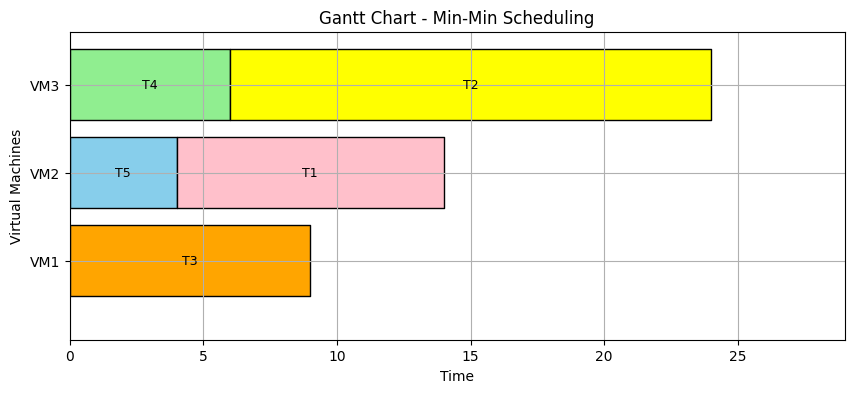


Min-Min Scheduling Completed Successfully.


In [5]:
# =================================================================
# Min-Min Scheduling Algorithm
# Cloud Computing Lab
# =================================================================
import matplotlib.pyplot as plt

# Execution Time Matrix (Rows = Tasks, Columns = Virtual Machines)
tasks = ["T1", "T2", "T3", "T4", "T5"]
vms = ["VM1", "VM2", "VM3"]
execution_time = [
    [14, 10, 12], #T1
    [16, 20, 18], #T2
    [9, 12, 10],  #T3
    [7, 8, 6],    #T4
    [5, 4, 7]     #T5
]

# Initialization
machine_ready = [0] * len(vms)
remaining_tasks = list(range(len(tasks)))
schedule = []

# Min-Min Scheduling
while remaining_tasks:
    minimum_completion = []
    for t in remaining_tasks:
        completion = []
        for vm in range(len(vms)):
            completion.append(machine_ready[vm] + execution_time[t][vm])
        min_time = min(completion)
        vm_index = completion.index(min_time)
        minimum_completion.append((t, vm_index, min_time))
        
    # Select task having minimum completion time
    selected = min(minimum_completion, key=lambda x: x[2])
    task = selected[0]
    vm = selected[1]
    finish = selected[2]
    
    start = machine_ready[vm]
    machine_ready[vm] = finish
    schedule.append((tasks[task], vms[vm], start, finish))
    remaining_tasks.remove(task)

# Display Results
print("=" * 75)
print(" MIN-MIN TASK SCHEDULING")
print("=" * 75)
print("{:<8}{:<8}{:<12}{:<12}".format("Task", "VM", "Start", "Finish"))

for item in schedule:
    print("{:<8}{:<8}{:<12}{:<12}".format(item[0], item[1], item[2], item[3]))

# Performance Metrics
makespan = max(machine_ready)
print("\nPerformance Metrics")
print("-" * 40)
print("Makespan:", makespan)

for i in range(len(vms)):
    print(vms[i], "Completion Time:", machine_ready[i])

# Gantt Chart
fig, ax = plt.subplots(figsize=(10, 4))
colors = ['skyblue', 'lightgreen', 'orange', 'pink', 'yellow']

for i, item in enumerate(schedule):
    task, vm, start, finish = item
    vm_index = vms.index(vm)
    ax.broken_barh([(start, finish-start)], (vm_index*10+5, 8), facecolors=colors[i % len(colors)], edgecolor='black')
    ax.text(start + (finish-start)/2, vm_index*10+9, task, ha='center', va='center', fontsize=9)

ax.set_xlim(0, makespan + 5)
ax.set_ylim(0, len(vms)*10+5)
ax.set_xlabel("Time")
ax.set_ylabel("Virtual Machines")
ax.set_yticks([9, 19, 29])
ax.set_yticklabels(vms)
ax.set_title("Gantt Chart - Min-Min Scheduling")
ax.grid(True)
plt.show()

print("\nMin-Min Scheduling Completed Successfully.")
